# 04 · Interpretabilidad

Proyecto de titulación · **Maestría en Inteligencia Artificial Aplicada (UDLA)**
Amapola Technologies Corp.

Responde la pregunta de fondo del trabajo: **¿qué explica el cumplimiento de un compromiso de
pago, y cuánto aporta realmente el comportamiento conversacional?**

Se interpretan **los dos modelos**, no solo uno:

- XGBoost operativo mediante valores SHAP, los cuales aportan magnitud, signo y forma de cada efecto por observación.
- Regresión logística operativa mediante sus coeficientes, dado que es el modelo con mejor PR-AUC en el test
  agregado (0,421 contra 0,393), así que ignorarla sería interpretar el modelo peor.

Si ambos coinciden en qué variables importan y en qué dirección, la conclusión es sólida. Si
discrepan, la discrepancia es el hallazgo.

> Los dos son modelos **observacionales**. SHAP y los coeficientes explican *cómo predice el
> modelo*, no *qué causa el pago*. Se usa vocabulario de asociación en todo el notebook.

## 0 · Configuración

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
import shap
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
SEMILLA = 42

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_OUTPUTS = RAIZ / "outputs"
DIR_FIGURAS = DIR_OUTPUTS / "figuras"
DIR_MODELOS = RAIZ / "modelos"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
ROJO = "#d03b3b"
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, REJILLA, EJE = "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.edgecolor": EJE,
    "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, rejilla="y"):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.grid(axis=rejilla, color=REJILLA, linewidth=0.8)
    ax.grid(axis="x" if rejilla == "y" else "y", visible=False)
    ax.tick_params(length=0)
    return ax

def titulos(ax, titulo, subtitulo=None):
    if subtitulo:
        ax.text(0, 1.13, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    else:
        ax.text(0, 1.035, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")

def guardar(fig, nombre):
    ruta = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(ruta)
    print(f"figura -> {ruta.relative_to(RAIZ)}")

print("shap:", shap.__version__)

shap: 0.51.0


---
## 1 · Reconstrucción de los dos modelos

In [2]:
df = pd.read_csv(DIR_OUTPUTS / "dataset_modelado_v1.csv",
                 dtype={"mes": str, "id_anonimo": str})
TARGET = "cumplimiento_conciliado"
CATEGORICAS = ["ultima_intencion_antes_compromiso", "tipo_operacion", "bucket"]

paquete = joblib.load(DIR_MODELOS / "xgboost_cumplimiento_v1.pkl")
FEATURES = paquete["features"]
MES_CORTE = paquete["mes_corte"]
print("Modelo cargado. Nota del paquete:")
print(" ", paquete["nota"])
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")

def preparar(d):
    X = d[FEATURES].copy()
    for c in FEATURES:
        X[c] = X[c].astype("category") if c in CATEGORICAS else pd.to_numeric(X[c], errors="coerce")
    return X

tr, te = df[df["mes"] < MES_CORTE], df[df["mes"] >= MES_CORTE]
y_tr, y_te = tr[TARGET].to_numpy(), te[TARGET].to_numpy()
X_tr, X_te = preparar(tr), preparar(te)

modelo = paquete["modelo"]
p_xgb = modelo.predict_proba(X_te)[:, 1]
print(f"\nXGBoost operativo  · PR-AUC en test: {average_precision_score(y_te, p_xgb):.4f}")

Modelo cargado. Nota del paquete:
  Modelo operativo: excluye activo_ya_pague por fuga temporal (mediana 0 dias respecto de fecha_pago).

Features (13): ['total_intenciones', 'intenciones_distintas', 'activo_compromiso', 'dias_compromiso', 'hora_primera_interaccion', 'dia_semana_primera_interaccion', 'dias_mora_inicial', 'meses_consecutivos_mora', 'mes_campania', 'tiene_conversacion', 'ultima_intencion_antes_compromiso', 'tipo_operacion', 'bucket']

XGBoost operativo  · PR-AUC en test: 0.3923


In [3]:
# La logistica se reconstruye con la misma receta de 03 para poder interpretarla
num = [c for c in FEATURES if c not in CATEGORICAS]
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]),
     CATEGORICAS),
])
logit = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=SEMILLA))])
logit.fit(tr[FEATURES], y_tr)
p_log = logit.predict_proba(te[FEATURES])[:, 1]
print(f"Logistica operativa · PR-AUC en test: {average_precision_score(y_te, p_log):.4f}")
print(f"\nCorrelacion de Spearman entre los dos rankings: "
      f"{pd.Series(p_xgb).corr(pd.Series(p_log), method='spearman'):.4f}")

Logistica operativa · PR-AUC en test: 0.4209

Correlacion de Spearman entre los dos rankings: 0.8990


---
## 2 · SHAP sobre XGBoost

Los valores SHAP reparten la predicción de cada observación entre las variables, en la escala
log-odds. A diferencia de la ganancia (que solo dice cuánto se usa una variable), traen **signo** y
**magnitud por observación**.

In [4]:
explicador = shap.TreeExplainer(modelo)
sv = explicador(X_te)
valores = sv.values
print("Matriz SHAP:", valores.shape)
print(f"Valor base (log-odds): {float(np.ravel(sv.base_values)[0]):.4f}")

importancia = (pd.DataFrame({
        "variable": FEATURES,
        "shap_medio_abs": np.abs(valores).mean(axis=0),
        "efecto_medio": valores.mean(axis=0),
    })
    .sort_values("shap_medio_abs", ascending=False)
    .reset_index(drop=True))
importancia["peso_rel"] = importancia["shap_medio_abs"] / importancia["shap_medio_abs"].sum()
display(importancia.round(4))

Matriz SHAP: (7502, 13)
Valor base (log-odds): 0.0095


,variable,shap_medio_abs,efecto_medio,peso_rel
0,dias_mora_inicial,0.8992,-0.4494,0.4018
1,meses_consecutivos_mora,0.5380,-0.2239,0.2404
2,ultima_intencion_antes_compromiso,0.1954,-0.0385,0.0873
3,intenciones_distintas,0.1879,-0.0384,0.0840
4,mes_campania,0.1611,-0.1451,0.0720
5,total_intenciones,0.0758,-0.0080,0.0339
6,bucket,0.0552,0.0104,0.0247
7,tipo_operacion,0.0399,-0.0218,0.0178
8,dias_compromiso,0.0378,-0.0124,0.0169
9,hora_primera_interaccion,0.0317,-0.0037,0.0142


figura -> outputs\figuras\22_shap_importancia.png


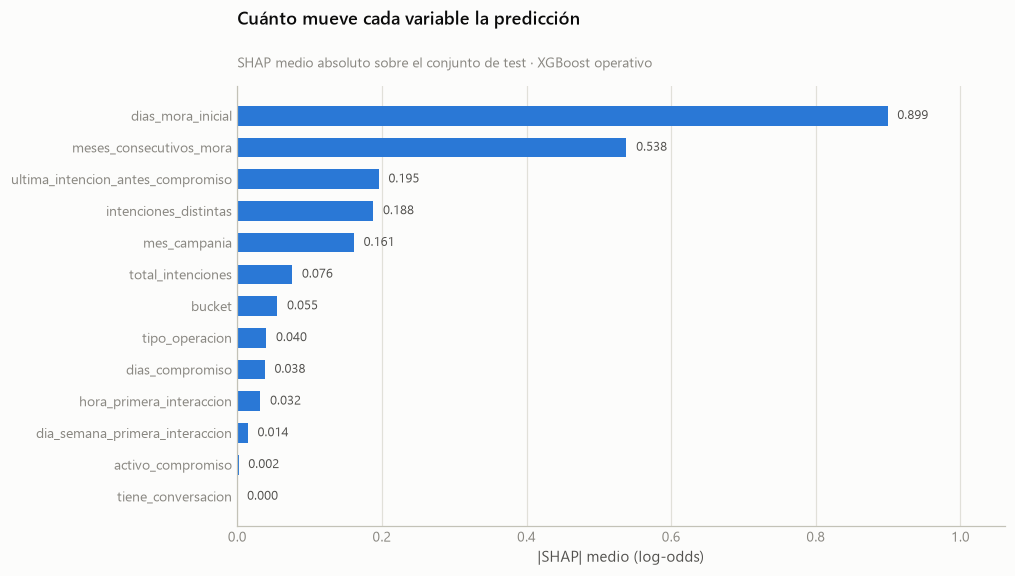

In [5]:
orden = importancia.sort_values("shap_medio_abs")
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(orden["variable"], orden["shap_medio_abs"], height=0.62, color=AZUL)
limpiar(ax, rejilla="x")
ax.set_xlabel("|SHAP| medio (log-odds)")
for y, v in enumerate(orden["shap_medio_abs"]):
    ax.text(v + orden["shap_medio_abs"].max() * 0.015, y, f"{v:.3f}",
            va="center", fontsize=8.5, color=TINTA_2)
ax.set_xlim(0, orden["shap_medio_abs"].max() * 1.18)
titulos(ax, "Cuánto mueve cada variable la predicción",
        "SHAP medio absoluto sobre el conjunto de test · XGBoost operativo")
guardar(fig, "22_shap_importancia")
plt.show()

### 2.1 · Dirección y forma del efecto

El |SHAP| medio dice cuánto pesa cada variable, no hacia dónde empuja. Un gráfico de dispersión de
valor contra efecto muestra ambas cosas, y además revela si la relación es monótona o tiene umbral.

figura -> outputs\figuras\23_shap_dependencia.png


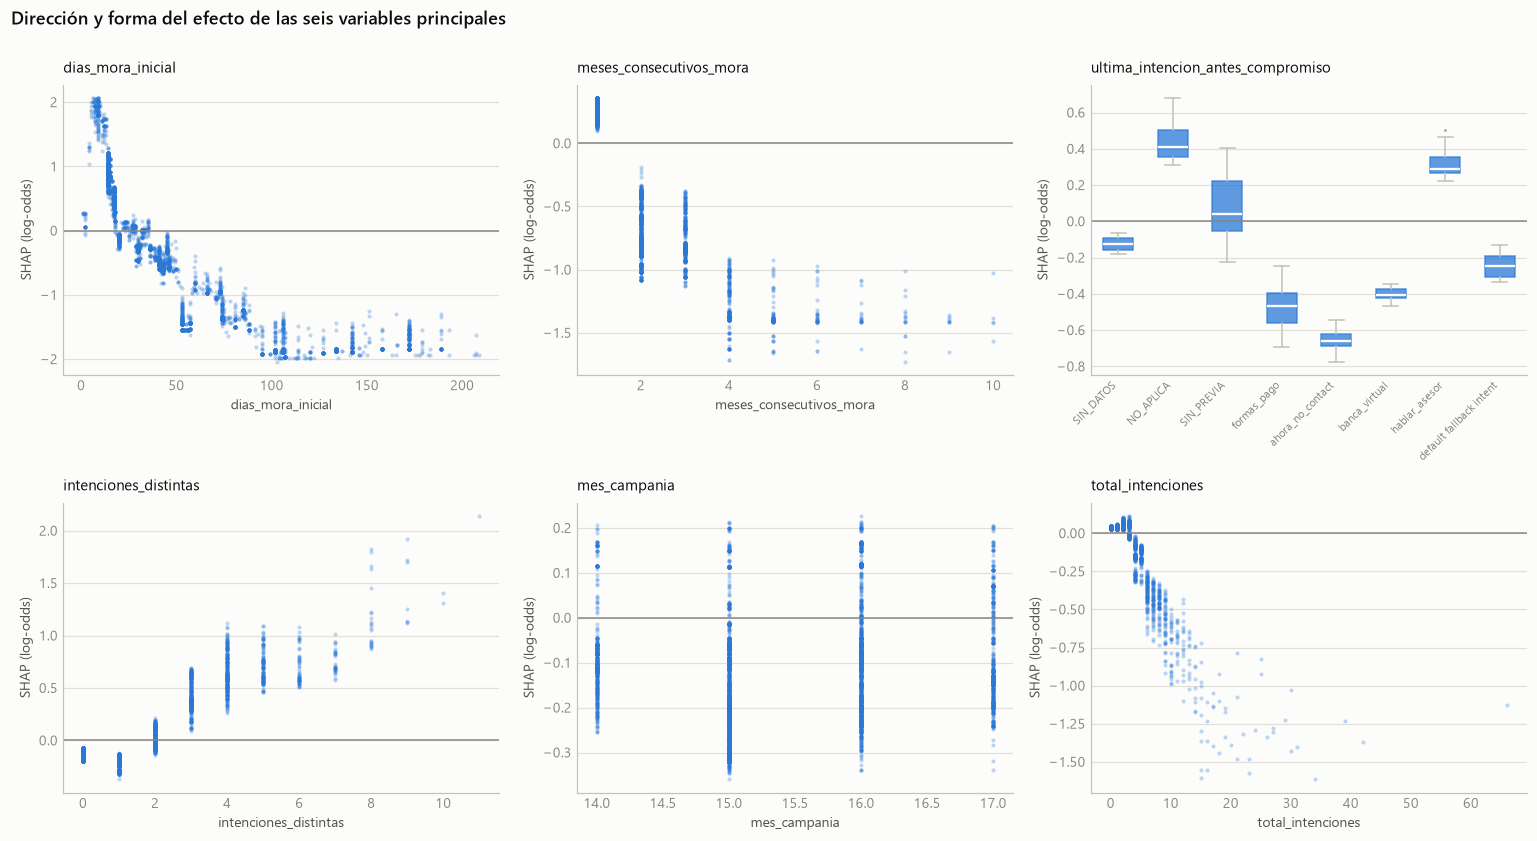

Por encima de cero la variable empuja hacia cumplir; por debajo, hacia no cumplir.


In [6]:
principales = importancia["variable"].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7.6))

for ax, var in zip(axes.ravel(), principales):
    j = FEATURES.index(var)
    y_shap = valores[:, j]
    col = X_te[var]

    if var in CATEGORICAS:
        cats = col.astype(str)
        top = cats.value_counts().head(8).index
        datos = [y_shap[(cats == c).to_numpy()] for c in top]
        ax.boxplot(datos, tick_labels=list(top), vert=True, widths=0.55,
                   patch_artist=True,
                   boxprops=dict(facecolor=AZUL, color=AZUL, alpha=0.75),
                   medianprops=dict(color=SUPERFICIE, linewidth=1.5),
                   whiskerprops=dict(color=EJE), capprops=dict(color=EJE),
                   flierprops=dict(markersize=2, markerfacecolor=MUTED,
                                   markeredgecolor="none", alpha=0.4))
        ax.tick_params(axis="x", rotation=45)
        for etiqueta in ax.get_xticklabels():
            etiqueta.set_ha("right")
            etiqueta.set_fontsize(7.5)
    else:
        x = pd.to_numeric(col, errors="coerce").to_numpy(dtype=float)
        finito = np.isfinite(x)
        ax.scatter(x[finito], y_shap[finito], s=7, color=AZUL, alpha=0.30,
                   linewidths=0, rasterized=True)
        nulos = (~finito).sum()
        if nulos:
            ax.scatter(np.full(nulos, np.nanmin(x) if np.isfinite(x).any() else 0),
                       y_shap[~finito], s=7, color=NARANJA, alpha=0.30, linewidths=0)
            ax.text(0.98, 0.04, f"{nulos:,} nulos en naranja", transform=ax.transAxes,
                    ha="right", fontsize=7.5, color=NARANJA)
        ax.set_xlabel(var, fontsize=9)

    ax.axhline(0, color=MUTED, linewidth=1)
    limpiar(ax)
    ax.set_ylabel("SHAP (log-odds)", fontsize=9)
    ax.set_title(var, loc="left", fontsize=10, color=TINTA, pad=8)

fig.suptitle("Dirección y forma del efecto de las seis variables principales",
             x=0.005, y=1.0, ha="left", fontsize=12, fontweight="600", color=TINTA)
fig.tight_layout()
guardar(fig, "23_shap_dependencia")
plt.show()
print("Por encima de cero la variable empuja hacia cumplir; por debajo, hacia no cumplir.")

---
## 3 · Coeficientes de la regresión logística

Con las numéricas estandarizadas, cada coeficiente es el cambio en log-odds por **una desviación
estándar** de la variable, así que son comparables entre sí. Se expresan también como *odds ratio*
(`exp(coef)`), que es la lectura más directa para la memoria.

In [7]:
nombres = logit.named_steps["pre"].get_feature_names_out()
coefs = logit.named_steps["clf"].coef_[0]
tabla_coef = (pd.DataFrame({"termino": nombres, "coeficiente": coefs})
              .assign(odds_ratio=lambda d: np.exp(d["coeficiente"]),
                      magnitud=lambda d: d["coeficiente"].abs())
              .sort_values("magnitud", ascending=False)
              .reset_index(drop=True))
tabla_coef["termino"] = tabla_coef["termino"].str.replace("^(num|cat)__", "", regex=True)
display(tabla_coef.round(4).head(20))

,termino,coeficiente,odds_ratio,magnitud
0,bucket_B6,2.3473,10.4569,2.3473
1,bucket_B1,-1.8444,0.1581,1.8444
2,bucket_B2,-1.2286,0.2927,1.2286
3,dias_mora_inicial,-1.1476,0.3174,1.1476
4,bucket_B5,0.9623,2.6177,0.9623
5,intenciones_distintas,0.7952,2.2148,0.7952
6,ultima_intencion_antes_compromiso_hablar_asesor,0.7650,2.1490,0.7650
7,meses_consecutivos_mora,-0.7101,0.4916,0.7101
8,ultima_intencion_antes_compromiso_ahora_no_con...,-0.6849,0.5041,0.6849
9,bucket_B7,0.6706,1.9554,0.6706


figura -> outputs\figuras\24_coeficientes_logistica.png


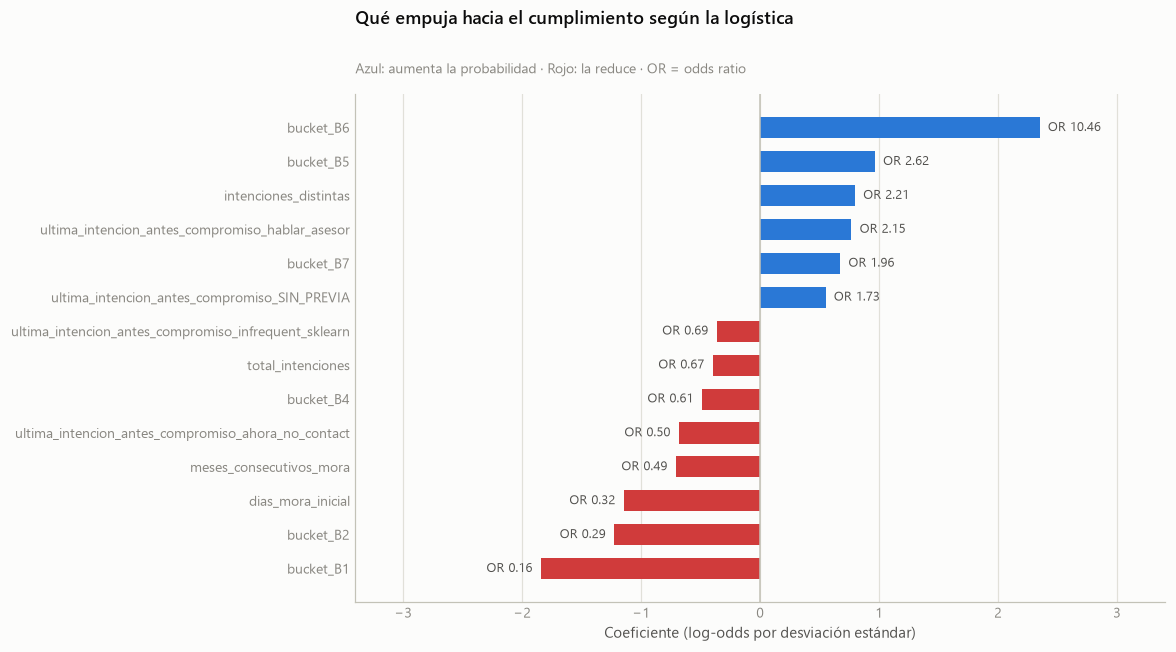

In [8]:
top = tabla_coef.head(14).sort_values("coeficiente")
colores = [AZUL if c > 0 else ROJO for c in top["coeficiente"]]

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(top["termino"], top["coeficiente"], height=0.62, color=colores)
ax.axvline(0, color=EJE, linewidth=1)
limpiar(ax, rejilla="x")
ax.set_xlabel("Coeficiente (log-odds por desviación estándar)")
rango = top["coeficiente"].abs().max()
for y, (v, orr) in enumerate(zip(top["coeficiente"], top["odds_ratio"])):
    desp = rango * 0.03
    ax.text(v + (desp if v > 0 else -desp), y, f"OR {orr:.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=8.5, color=TINTA_2)
ax.set_xlim(-rango * 1.45, rango * 1.45)
titulos(ax, "Qué empuja hacia el cumplimiento según la logística",
        "Azul: aumenta la probabilidad · Rojo: la reduce · OR = odds ratio")
guardar(fig, "24_coeficientes_logistica")
plt.show()

### 3.1 · Dos coeficientes que no deben leerse literalmente

La tabla anterior contiene dos trampas clásicas de la regresión con variables correlacionadas. Si
se copian tal cual a la memoria, afirman cosas falsas.

**`total_intenciones` sale negativa (−0,40)** cuando en el EDA correlacionaba **+0,200** con el
cumplimiento. No cambió de signo la realidad: cambió el condicionamiento. `total_intenciones` e
`intenciones_distintas` tienen una correlación de Spearman de 0,997, de modo que son prácticamente la
misma variable. Cuando dos regresores casi idénticos entran juntos, el modelo reparte el efecto
entre ambos de forma arbitraria y a menudo con signos opuestos, porque solo la *diferencia* entre
ellos aporta información nueva.

**`bucket_B6` aparece con odds ratio 10,5**, el coeficiente más grande de todos. Pero B6 tiene una
tasa de cumplimiento de **3,9 %**, de las más bajas de la cartera. El bucket es esencialmente una
discretización de `dias_mora_inicial`, que ya está en el modelo como variable continua: el
coeficiente de B6 no dice "estar en B6 aumenta la probabilidad de pagar", dice "dentro de los
clientes con la mora continua de B6, estar clasificado en B6 corrige hacia arriba respecto de lo
que la variable continua predeciría". Es un ajuste residual, no un efecto.

La celda siguiente lo verifica en vez de dejarlo como afirmación.

In [9]:
print("Colinealidad entre los dos contadores de intenciones:")
print(f"   Spearman : {df['total_intenciones'].corr(df['intenciones_distintas'], method='spearman'):.4f}")
print(f"   Pearson  : {df['total_intenciones'].corr(df['intenciones_distintas']):.4f}")
print("\nCorrelacion individual de cada uno con el target:")
for c in ["total_intenciones", "intenciones_distintas"]:
    print(f"   {c:<24}: {df[c].corr(df[TARGET], method='spearman'):+.4f}")

print("\nTasa de cumplimiento real por bucket (contrastar con los odds ratio):")
print(df.groupby("bucket")[TARGET].agg(n="size", tasa="mean").round(4).to_string())

print("\nLectura correcta: SHAP no sufre este problema del mismo modo, porque reparte el")
print("efecto observacion por observacion sobre el modelo ya ajustado. Por eso, cuando los")
print("dos metodos discrepan, conviene fiarse de la lectura marginal del EDA para la")
print("DIRECCION y de SHAP para la MAGNITUD, y tratar los coeficientes como lo que son:")
print("efectos condicionados al resto de variables del modelo.")

Colinealidad entre los dos contadores de intenciones:


   Spearman : 0.9972
   Pearson  : 0.7978

Correlacion individual de cada uno con el target:
   total_intenciones       : +0.1999
   intenciones_distintas   : +0.2063

Tasa de cumplimiento real por bucket (contrastar con los odds ratio):
           n    tasa
bucket              
B1      7573  0.2667
B2      7826  0.1910
B3      1329  0.1746
B4       677  0.0340
B5       455  0.0198
B6       659  0.0395
B7        61  0.0328

Lectura correcta: SHAP no sufre este problema del mismo modo, porque reparte el
efecto observacion por observacion sobre el modelo ya ajustado. Por eso, cuando los
dos metodos discrepan, conviene fiarse de la lectura marginal del EDA para la
DIRECCION y de SHAP para la MAGNITUD, y tratar los coeficientes como lo que son:
efectos condicionados al resto de variables del modelo.


---
## 4 · ¿Coinciden los dos modelos?

Si dos familias de modelos distintas, ajustadas por separado, ordenan las variables de forma
parecida y con el mismo signo, la conclusión no depende del algoritmo. Esa es la comparación que
da solidez a la interpretación.

In [10]:
# Para comparar, los terminos one-hot de la logistica se agregan por variable de origen
def variable_origen(termino):
    for c in CATEGORICAS:
        if termino.startswith(c):
            return c
    return termino

resumen_logit = (tabla_coef.assign(variable=tabla_coef["termino"].map(variable_origen))
                 .groupby("variable")
                 .agg(coef_max_abs=("magnitud", "max"),
                      coef_signo=("coeficiente", lambda s: np.sign(s.iloc[s.abs().argmax()])))
                 .reset_index())

comparacion = (importancia[["variable", "shap_medio_abs", "efecto_medio"]]
               .merge(resumen_logit, on="variable", how="outer"))
comparacion["rank_shap"] = comparacion["shap_medio_abs"].rank(ascending=False)
comparacion["rank_logit"] = comparacion["coef_max_abs"].rank(ascending=False)
comparacion["dif_rank"] = (comparacion["rank_shap"] - comparacion["rank_logit"]).abs()
comparacion = comparacion.sort_values("rank_shap")
display(comparacion.round(4))

rho = comparacion["rank_shap"].corr(comparacion["rank_logit"], method="spearman")
print(f"\nCorrelacion de Spearman entre los dos ordenamientos: {rho:.3f}")

,variable,shap_medio_abs,efecto_medio,coef_max_abs,coef_signo,rank_shap,rank_logit,dif_rank
4,dias_mora_inicial,0.8992,-0.4494,1.1476,-1.0,1.0,2.0,1.0
8,meses_consecutivos_mora,0.5380,-0.2239,0.7101,-1.0,2.0,5.0,3.0
12,ultima_intencion_antes_compromiso,0.1954,-0.0385,0.7650,1.0,3.0,4.0,1.0
6,intenciones_distintas,0.1879,-0.0384,0.7952,1.0,4.0,3.0,1.0
7,mes_campania,0.1611,-0.1451,0.1870,-1.0,5.0,9.0,4.0
11,total_intenciones,0.0758,-0.0080,0.3996,-1.0,6.0,6.0,0.0
1,bucket,0.0552,0.0104,2.3473,1.0,7.0,1.0,6.0
10,tipo_operacion,0.0399,-0.0218,0.2740,1.0,8.0,8.0,0.0
3,dias_compromiso,0.0378,-0.0124,0.1665,-1.0,9.0,10.0,1.0
5,hora_primera_interaccion,0.0317,-0.0037,0.0328,1.0,10.0,12.0,2.0



Correlacion de Spearman entre los dos ordenamientos: 0.720


figura -> outputs\figuras\25_concordancia_modelos.png


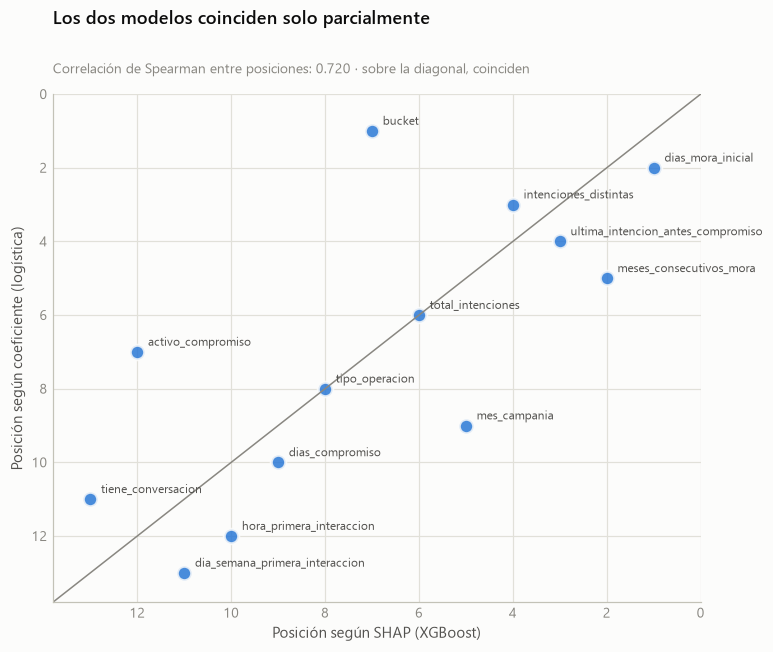

In [11]:
fig, ax = plt.subplots(figsize=(7.6, 6))
ax.scatter(comparacion["rank_shap"], comparacion["rank_logit"], s=90,
           color=AZUL, alpha=0.85, edgecolors=SUPERFICIE, linewidths=2)
lim = comparacion[["rank_shap", "rank_logit"]].max().max() + 0.8
ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1)
for _, r in comparacion.iterrows():
    ax.annotate(r["variable"], (r["rank_shap"], r["rank_logit"]),
                textcoords="offset points", xytext=(7, 4), fontsize=7.8, color=TINTA_2)
limpiar(ax)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_xlabel("Posición según SHAP (XGBoost)")
ax.set_ylabel("Posición según coeficiente (logística)")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.invert_xaxis(); ax.invert_yaxis()
acuerdo = "casi igual" if rho > 0.85 else "solo parcialmente"
titulos(ax, f"Los dos modelos coinciden {acuerdo}",
        f"Correlación de Spearman entre posiciones: {rho:.3f} · sobre la diagonal, coinciden")
guardar(fig, "25_concordancia_modelos")
plt.show()

---
## 5 · La pregunta del trabajo: ¿cuánto aporta lo conversacional?

Hasta aquí se ha visto cuánto pesa cada variable dentro de cada modelo. Falta lo que realmente
importa para la tesis: **si se quitan las variables conversacionales, ¿cuánto se pierde?** Es la
única medida directa del valor incremental del chatbot como fuente de datos.

In [12]:
CONVERSACIONALES = ["total_intenciones", "intenciones_distintas", "activo_compromiso",
                    "dias_compromiso", "ultima_intencion_antes_compromiso",
                    "hora_primera_interaccion", "dia_semana_primera_interaccion",
                    "tiene_conversacion"]
CARTERA = [c for c in FEATURES if c not in CONVERSACIONALES]

print("Bloque conversacional:", CONVERSACIONALES)
print("Bloque de cartera    :", CARTERA)

def entrenar_logit(feats):
    n = [c for c in feats if c not in CATEGORICAS]
    c = [x for x in CATEGORICAS if x in feats]
    pasos = [("num", Pipeline([("i", SimpleImputer(strategy="median")),
                               ("s", StandardScaler())]), n)]
    if c:
        pasos.append(("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                                       ("o", OneHotEncoder(handle_unknown="ignore",
                                                           min_frequency=20))]), c))
    modelo = Pipeline([("pre", ColumnTransformer(pasos)),
                       ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                  random_state=SEMILLA))])
    modelo.fit(tr[feats], y_tr)
    return average_precision_score(y_te, modelo.predict_proba(te[feats])[:, 1])

def entrenar_xgb(feats):
    def prep(d):
        X = d[feats].copy()
        for col in feats:
            X[col] = (X[col].astype("category") if col in CATEGORICAS
                      else pd.to_numeric(X[col], errors="coerce"))
        return X
    m = xgb.XGBClassifier(objective="binary:logistic", eval_metric="aucpr",
                          tree_method="hist", enable_categorical=True,
                          scale_pos_weight=float(paquete["scale_pos_weight"]),
                          random_state=SEMILLA, n_jobs=-1,
                          **paquete["hiperparametros"]).fit(prep(tr), y_tr)
    return average_precision_score(y_te, m.predict_proba(prep(te))[:, 1])

bloques = {
    "Solo cartera": CARTERA,
    "Solo conversacional": CONVERSACIONALES,
    "Ambos (modelo completo)": FEATURES,
}
filas = []
for nombre, feats in bloques.items():
    filas.append({"conjunto": nombre, "n_variables": len(feats),
                  "PR_AUC_logistica": entrenar_logit(feats),
                  "PR_AUC_xgboost": entrenar_xgb(feats)})
ablacion = pd.DataFrame(filas)
ablacion["lift_logistica"] = ablacion["PR_AUC_logistica"] / y_te.mean()
ablacion["lift_xgboost"] = ablacion["PR_AUC_xgboost"] / y_te.mean()
display(ablacion.round(4))

sc = ablacion.set_index("conjunto")
print(f"\nTasa base en test: {y_te.mean():.4f}")
print(f"\nAporte del bloque conversacional (sobre solo cartera):")
print(f"   logistica: {sc.loc['Solo cartera','PR_AUC_logistica']:.4f} -> "
      f"{sc.loc['Ambos (modelo completo)','PR_AUC_logistica']:.4f}  "
      f"({sc.loc['Ambos (modelo completo)','PR_AUC_logistica'] - sc.loc['Solo cartera','PR_AUC_logistica']:+.4f})")
print(f"   xgboost  : {sc.loc['Solo cartera','PR_AUC_xgboost']:.4f} -> "
      f"{sc.loc['Ambos (modelo completo)','PR_AUC_xgboost']:.4f}  "
      f"({sc.loc['Ambos (modelo completo)','PR_AUC_xgboost'] - sc.loc['Solo cartera','PR_AUC_xgboost']:+.4f})")

Bloque conversacional: ['total_intenciones', 'intenciones_distintas', 'activo_compromiso', 'dias_compromiso', 'ultima_intencion_antes_compromiso', 'hora_primera_interaccion', 'dia_semana_primera_interaccion', 'tiene_conversacion']
Bloque de cartera    : ['dias_mora_inicial', 'meses_consecutivos_mora', 'mes_campania', 'tipo_operacion', 'bucket']


,conjunto,n_variables,PR_AUC_logistica,PR_AUC_xgboost,lift_logistica,lift_xgboost
0,Solo cartera,5,0.3191,0.3413,1.8499,1.9787
1,Solo conversacional,8,0.3492,0.3436,2.0244,1.9922
2,Ambos (modelo completo),13,0.4209,0.3926,2.4400,2.2763



Tasa base en test: 0.1725

Aporte del bloque conversacional (sobre solo cartera):
   logistica: 0.3191 -> 0.4209  (+0.1018)
   xgboost  : 0.3413 -> 0.3926  (+0.0513)


figura -> outputs\figuras\26_ablacion_bloques.png


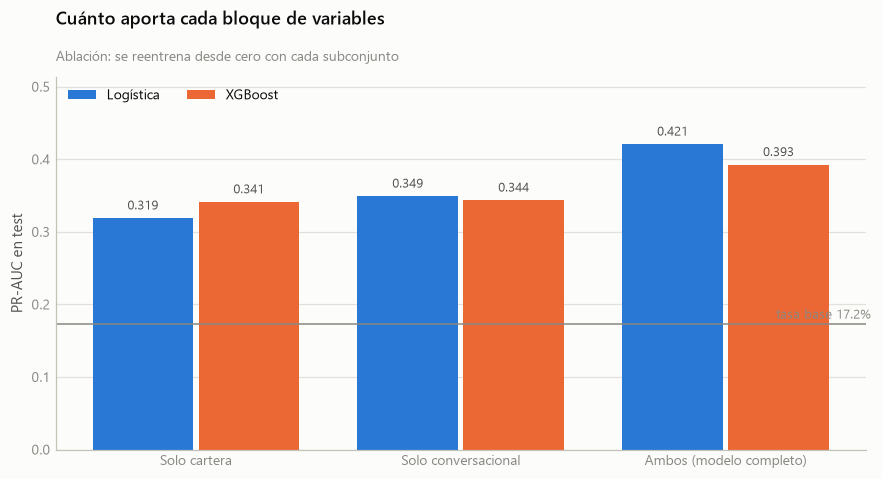

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(ablacion))
ancho = 0.38
ax.bar(x - ancho/2 - 0.01, ablacion["PR_AUC_logistica"], ancho, color=AZUL, label="Logística")
ax.bar(x + ancho/2 + 0.01, ablacion["PR_AUC_xgboost"], ancho, color=NARANJA, label="XGBoost")
ax.axhline(y_te.mean(), color=MUTED, linewidth=1)
ax.text(len(ablacion) - 0.45, y_te.mean() + 0.008, f"tasa base {y_te.mean():.1%}",
        ha="right", fontsize=8.5, color=MUTED)
limpiar(ax)
ax.set_xticks(x)
ax.set_xticklabels(ablacion["conjunto"])
ax.set_ylabel("PR-AUC en test")
for xi, (a, b) in enumerate(zip(ablacion["PR_AUC_logistica"], ablacion["PR_AUC_xgboost"])):
    ax.text(xi - ancho/2 - 0.01, a + 0.008, f"{a:.3f}", ha="center", va="bottom",
            fontsize=8.5, color=TINTA_2)
    ax.text(xi + ancho/2 + 0.01, b + 0.008, f"{b:.3f}", ha="center", va="bottom",
            fontsize=8.5, color=TINTA_2)
ax.set_ylim(0, max(ablacion[["PR_AUC_logistica", "PR_AUC_xgboost"]].max()) * 1.22)
ax.legend(loc="upper left", ncols=2)
titulos(ax, "Cuánto aporta cada bloque de variables",
        "Ablación: se reentrena desde cero con cada subconjunto")
guardar(fig, "26_ablacion_bloques")
plt.show()

---
## 6 · Casos individuales

In [14]:
idx_orden = np.argsort(-p_xgb)
casos = {"Mayor probabilidad": idx_orden[0],
         "Menor probabilidad": idx_orden[-1],
         "Cerca del umbral": idx_orden[len(idx_orden) // 2]}

for nombre, i in casos.items():
    contrib = (pd.DataFrame({"variable": FEATURES,
                             "valor": [X_te.iloc[i][c] for c in FEATURES],
                             "shap": valores[i]})
               .assign(magnitud=lambda d: d["shap"].abs())
               .sort_values("magnitud", ascending=False)
               .head(6))
    print(f"\n{'=' * 62}")
    print(f"{nombre} | p={p_xgb[i]:.3f} | real={y_te[i]}")
    print("=" * 62)
    print(contrib[["variable", "valor", "shap"]].to_string(index=False))


Mayor probabilidad | p=0.951 | real=1
                         variable     valor     shap
                dias_mora_inicial         8 1.893567
ultima_intencion_antes_compromiso NO_APLICA 0.358066
                           bucket        B3 0.277505
          meses_consecutivos_mora         1 0.218698
                   tipo_operacion   CARTERA 0.122452
                total_intenciones         2 0.055355

Menor probabilidad | p=0.018 | real=1
                         variable     valor      shap
                dias_mora_inicial       105 -1.987092
          meses_consecutivos_mora         7 -1.414627
            intenciones_distintas         0 -0.190650
ultima_intencion_antes_compromiso SIN_DATOS -0.180271
                           bucket        B1 -0.075708
         hora_primera_interaccion       NaN -0.061957

Cerca del umbral | p=0.351 | real=0
                         variable       valor      shap
ultima_intencion_antes_compromiso formas_pago -0.601388
          meses_consecut

---
## 7 · Conclusiones

In [15]:
top3 = importancia["variable"].head(3).tolist()
conv_shap = importancia[importancia["variable"].isin(CONVERSACIONALES)]["shap_medio_abs"].sum()
total_shap = importancia["shap_medio_abs"].sum()
sc = ablacion.set_index("conjunto")

print("=" * 74)
print("CONCLUSIONES DE INTERPRETABILIDAD")
print("=" * 74)
print(f"""
1. Coincidencia entre modelos: parcial
   Correlacion de Spearman entre el orden de SHAP y el de los coeficientes: {rho:.3f}
   Coinciden en lo esencial (la mora manda) pero discrepan en bucket, que la
   logistica infla por colinealidad con dias_mora_inicial. Ver seccion 3.1.

2. Que manda
   Top 3 por SHAP: {', '.join(top3)}
   El bloque conversacional concentra {conv_shap/total_shap:.1%} del |SHAP| total.
   El predictor individual mas fuerte sigue siendo la mora, no la conversacion.

3. Aporte incremental del chatbot (ablacion, PR-AUC en test)
   Solo cartera        : logistica {sc.loc['Solo cartera','PR_AUC_logistica']:.4f} | xgboost {sc.loc['Solo cartera','PR_AUC_xgboost']:.4f}
   Solo conversacional : logistica {sc.loc['Solo conversacional','PR_AUC_logistica']:.4f} | xgboost {sc.loc['Solo conversacional','PR_AUC_xgboost']:.4f}
   Ambos               : logistica {sc.loc['Ambos (modelo completo)','PR_AUC_logistica']:.4f} | xgboost {sc.loc['Ambos (modelo completo)','PR_AUC_xgboost']:.4f}
   tasa base           : {y_te.mean():.4f}

4. Limites que deben constar en la memoria
   - Asociacion, no causalidad. El chatbot registra conversacion solo cuando el
     cliente contesta; parte del efecto es de quien contesta, no del canal.
   - Los coeficientes de total_intenciones y bucket NO deben leerse literalmente:
     son artefactos de colinealidad (Spearman 0.997 entre los dos contadores de
     intenciones; bucket es una discretizacion de dias_mora_inicial). Seccion 3.1.
   - El modelo se entreno sobre clientes gestionados en cobranza con mora > 0.
     No extrapola a cuentas al dia ni al flujo de convenio.
   - Tres meses de test. La comparacion entre familias de modelos no es estable
     mes a mes (ver 03, seccion 4.1c).
""")

CONCLUSIONES DE INTERPRETABILIDAD

1. Coincidencia entre modelos: parcial
   Correlacion de Spearman entre el orden de SHAP y el de los coeficientes: 0.720
   Coinciden en lo esencial (la mora manda) pero discrepan en bucket, que la
   logistica infla por colinealidad con dias_mora_inicial. Ver seccion 3.1.

2. Que manda
   Top 3 por SHAP: dias_mora_inicial, meses_consecutivos_mora, ultima_intencion_antes_compromiso
   El bloque conversacional concentra 24.3% del |SHAP| total.
   El predictor individual mas fuerte sigue siendo la mora, no la conversacion.

3. Aporte incremental del chatbot (ablacion, PR-AUC en test)
   Solo cartera        : logistica 0.3191 | xgboost 0.3413
   Solo conversacional : logistica 0.3492 | xgboost 0.3436
   Ambos               : logistica 0.4209 | xgboost 0.3926
   tasa base           : 0.1725

4. Limites que deben constar en la memoria
   - Asociacion, no causalidad. El chatbot registra conversacion solo cuando el
     cliente contesta; parte del efecto es 

---
### Cierre del proyecto

Las cuatro fases están completas. Lo que queda es material para la memoria, no para el código:

- Redactar el OE3 reflejando la comparación entre familias de modelos en lugar de declarar una
  ganadora a priori.
- Consultar a Amapola por las dos celdas mes × lote sin conciliación (ver 02, sección 6.2).
- Si aparecen los CSV de gestión y pagos anteriores a julio 2025, el pipeline los absorbe sin
  cambios y la ventana se amplía, dado que más datos constituye la vía más probable para que el boosting alcance
  a la línea base.